# Notebook 2: Classical Time Series Models
## ARIMA · STL Decomposition · Exponential Smoothing

---

### Objectives
1. **ARIMA** — Fit ARIMA(p,d,q) on log-returns; identify optimal orders via AIC/BIC grid search
2. **STL Decomposition** — Decompose Nifty 50 price into trend, seasonality, residual
3. **Exponential Smoothing (Holt-Winters)** — Simple, Double, Triple smoothing as baseline forecasts
4. **Forecast evaluation** — RMSE, MAE, MAPE on a held-out test set
5. **Residual diagnostics** → check for ARCH effects (motivation for Notebook 3)

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import os, itertools

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False
})
PALETTE = ['#2563eb', '#dc2626', '#16a34a', '#d97706', '#7c3aed']

# ── Load data from Notebook 1 ─────────────────────────────────────────────────
master = pd.read_csv('data/nifty50_master.csv', index_col=0, parse_dates=True)
print('Data loaded:', master.shape)

# Train/test split — last 252 trading days (~1 year) as test set
TEST_SIZE = 252
train = master.iloc[:-TEST_SIZE]
test  = master.iloc[-TEST_SIZE:]

print(f'Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} days)')
print(f'Test : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} days)')

Data loaded: (3678, 5)
Train: 2010-01-05 → 2023-12-19 (3426 days)
Test : 2023-12-20  → 2024-12-30  (252 days)


## 1. ARIMA Model

### 1a. Order identification via AIC/BIC grid search

We search over p ∈ {0..4}, q ∈ {0..4} with d=0 (log-returns are stationary).

In [2]:
r_train = train['log_ret'].dropna()
r_test  = test['log_ret'].dropna()

print('Grid search: ARIMA(p, 0, q) on log-returns ...')
print('(This may take ~1–2 minutes)\n')

results_grid = []
for p, q in itertools.product(range(5), range(5)):
    if p == 0 and q == 0:
        continue
    try:
        m = ARIMA(r_train, order=(p, 0, q)).fit()
        results_grid.append({'p': p, 'q': q, 'AIC': m.aic, 'BIC': m.bic, 'LL': m.llf})
    except Exception:
        pass

grid_df = pd.DataFrame(results_grid).sort_values('AIC')
print('Top 10 models by AIC:')
print(grid_df.head(10).to_string(index=False))

best_p = int(grid_df.iloc[0]['p'])
best_q = int(grid_df.iloc[0]['q'])
print(f'\n→ Best model by AIC: ARIMA({best_p}, 0, {best_q})')

Grid search: ARIMA(p, 0, q) on log-returns ...
(This may take ~1–2 minutes)



C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasti

Top 10 models by AIC:
 p  q           AIC           BIC           LL
 3  4 -21389.296078 -21334.043740 10703.648039
 2  4 -21374.674923 -21325.561734 10695.337462
 1  4 -21352.246536 -21309.272496 10683.123268
 1  0 -21345.472158 -21327.054712 10675.736079
 0  1 -21345.464298 -21327.046852 10675.732149
 0  2 -21343.530534 -21318.973940 10675.765267
 2  0 -21343.529786 -21318.973191 10675.764893
 1  1 -21343.512789 -21318.956195 10675.756395
 1  3 -21342.455073 -21305.620181 10677.227536
 3  0 -21341.563294 -21310.867551 10675.781647

→ Best model by AIC: ARIMA(3, 0, 4)


In [3]:
# ── Fit best ARIMA ─────────────────────────────────────────────────────────────
arima_model = ARIMA(r_train, order=(best_p, 0, best_q)).fit()
print(arima_model.summary())

C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

                               SARIMAX Results                                
Dep. Variable:                log_ret   No. Observations:                 3426
Model:                 ARIMA(3, 0, 4)   Log Likelihood               10703.648
Date:                Thu, 02 Apr 2026   AIC                         -21389.296
Time:                        17:16:15   BIC                         -21334.044
Sample:                             0   HQIC                        -21369.556
                               - 3426                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.923      0.055   -7.51e-06       0.001
ar.L1         -0.9066      0.231     -3.918      0.000      -1.360      -0.453
ar.L2          0.1264      0.369      0.342      0.7

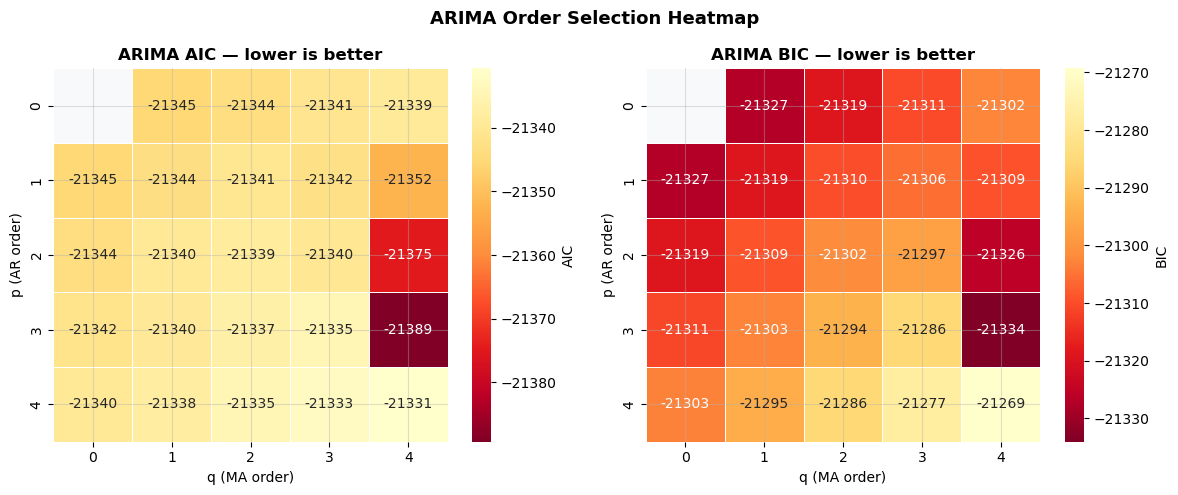

In [4]:
# ── AIC/BIC heatmap ───────────────────────────────────────────────────────────
aic_pivot = grid_df.pivot(index='p', columns='q', values='AIC')
bic_pivot = grid_df.pivot(index='p', columns='q', values='BIC')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(axes, [aic_pivot, bic_pivot], ['AIC', 'BIC']):
    sns.heatmap(data, annot=True, fmt='.0f', cmap='YlOrRd_r', ax=ax, 
                linewidths=0.5, cbar_kws={'label': title})
    ax.set_title(f'ARIMA {title} — lower is better', fontweight='bold')
    ax.set_xlabel('q (MA order)'); ax.set_ylabel('p (AR order)')

plt.suptitle('ARIMA Order Selection Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_arima_order_selection.png', dpi=150, bbox_inches='tight')
plt.show()

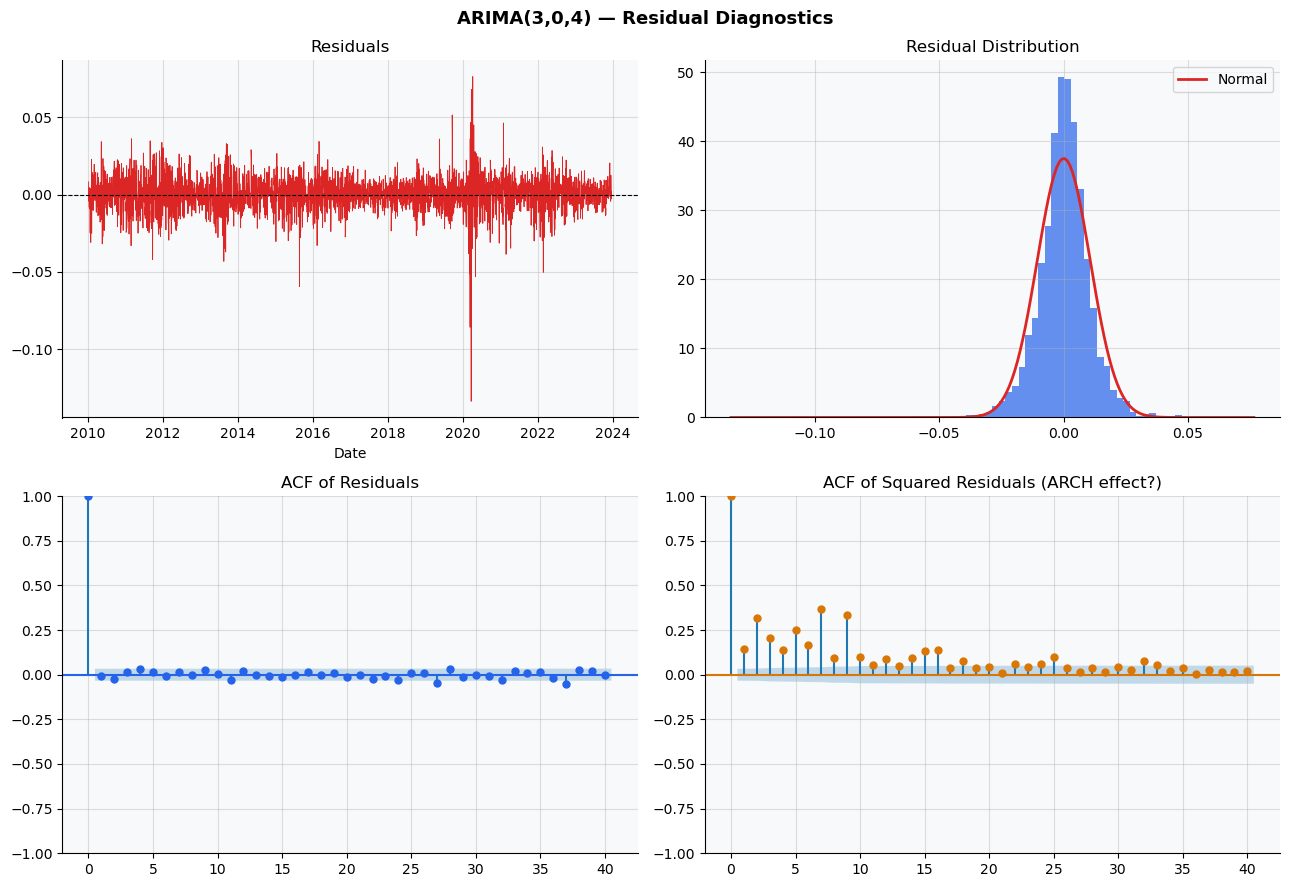

Ljung-Box on residuals (H₀: no autocorrelation):
      lb_stat  lb_pvalue
10  10.791299   0.374007
20  17.799796   0.600595

Ljung-Box on squared residuals (ARCH effect test):
        lb_stat  lb_pvalue
10  1853.162181        0.0
20  2090.282185        0.0

ARCH LM Test: stat=841.4243, p-value=0.000000
✓ ARCH effects detected in residuals → proceed to GARCH in Notebook 3


In [5]:
# ── ARIMA Residual Diagnostics ────────────────────────────────────────────────
residuals = arima_model.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'ARIMA({best_p},0,{best_q}) — Residual Diagnostics', fontsize=13, fontweight='bold')

# Residual plot
axes[0,0].plot(residuals.index, residuals, color=PALETTE[1], linewidth=0.6)
axes[0,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,0].set_title('Residuals'); axes[0,0].set_xlabel('Date')

# Residual histogram
axes[0,1].hist(residuals, bins=80, density=True, color=PALETTE[0], alpha=0.7)
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[0,1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 
               color=PALETTE[1], linewidth=2, label='Normal')
axes[0,1].set_title('Residual Distribution'); axes[0,1].legend()

# ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1,0], color=PALETTE[0])
axes[1,0].set_title('ACF of Residuals')

# ACF of squared residuals (ARCH test)
plot_acf(residuals**2, lags=40, ax=axes[1,1], color=PALETTE[3])
axes[1,1].set_title('ACF of Squared Residuals (ARCH effect?)')

plt.tight_layout()
plt.savefig('plots/06_arima_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Formal tests
lb_resid = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
lb_sq    = acorr_ljungbox(residuals**2, lags=[10, 20], return_df=True)
arch_lm  = het_arch(residuals)

print('Ljung-Box on residuals (H₀: no autocorrelation):')
print(lb_resid.to_string()); print()
print('Ljung-Box on squared residuals (ARCH effect test):')
print(lb_sq.to_string()); print()
print(f'ARCH LM Test: stat={arch_lm[0]:.4f}, p-value={arch_lm[1]:.6f}')
if arch_lm[1] < 0.05:
    print('✓ ARCH effects detected in residuals → proceed to GARCH in Notebook 3')

# Save residuals for use in Notebook 3
residuals.to_csv('data/arima_residuals.csv', header=True)

Computing rolling 1-step-ahead forecast on 252 test observations ...


C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step 0/252


C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:6

  Step 50/252


...

  Step 150/252


C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:6

  Step 200/252


C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\base\model.py:6

  Step 250/252

ARIMA(3,0,4) Forecast Metrics
  RMSE : 0.008971
  MAE  : 0.006121
  Directional accuracy: 54.58%


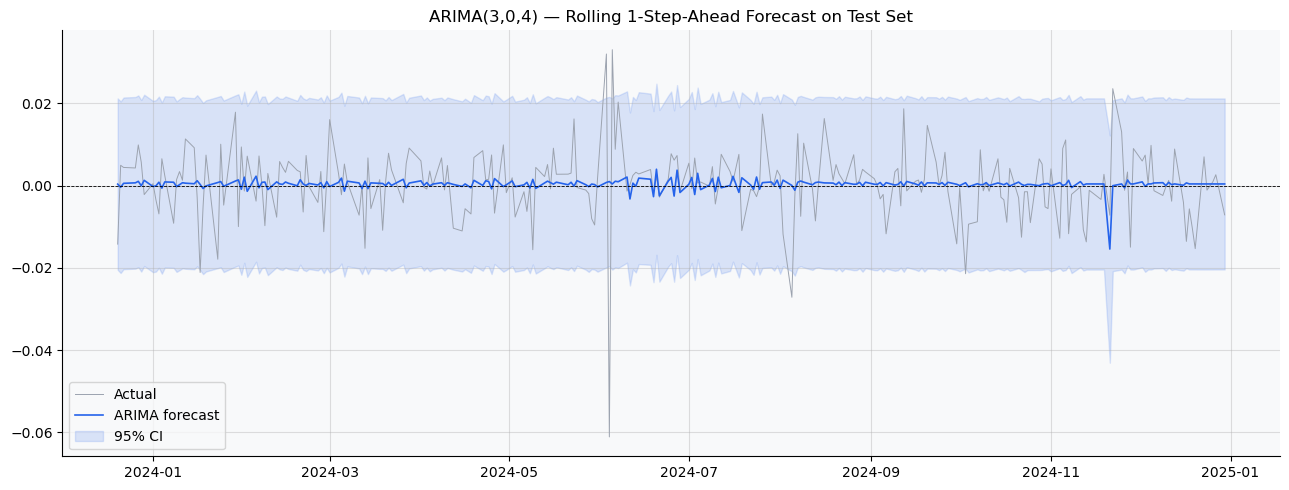

In [13]:
# ── ARIMA Forecast ────────────────────────────────────────────────────────────
# Rolling one-step-ahead forecast on test set
print(f'Computing rolling 1-step-ahead forecast on {len(r_test)} test observations ...')

history = list(r_train)
predictions = []
conf_lower  = []
conf_upper  = []

for t in range(len(r_test)):
    model = ARIMA(history, order=(best_p, 0, best_q)).fit()
    fc    = model.get_forecast(steps=1)
    predictions.append(fc.predicted_mean[0])
    ci = fc.conf_int(alpha=0.05)
    conf_lower.append(ci[0, 0])
    conf_upper.append(ci[0, 1])
    history.append(r_test.iloc[t])
    if t % 50 == 0:
        print(f'  Step {t}/{len(r_test)}')

pred_series = pd.Series(predictions, index=r_test.index)
ci_lo = pd.Series(conf_lower, index=r_test.index)
ci_hi = pd.Series(conf_upper, index=r_test.index)

# Metrics
rmse = np.sqrt(np.mean((r_test.values - pred_series.values)**2))
mae  = np.mean(np.abs(r_test.values - pred_series.values))
print(f'\nARIMA({best_p},0,{best_q}) Forecast Metrics')
print(f'  RMSE : {rmse:.6f}')
print(f'  MAE  : {mae:.6f}')

# Directional accuracy
dir_acc = np.mean(np.sign(r_test.values[1:]) == np.sign(pred_series.values[:-1]))
print(f'  Directional accuracy: {dir_acc:.2%}')

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(r_test.index, r_test, color='#9ca3af', linewidth=0.7, label='Actual')
ax.plot(pred_series.index, pred_series, color=PALETTE[0], linewidth=1.2, label='ARIMA forecast')
ax.fill_between(pred_series.index, ci_lo, ci_hi, alpha=0.15, color=PALETTE[0], label='95% CI')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title(f'ARIMA({best_p},0,{best_q}) — Rolling 1-Step-Ahead Forecast on Test Set')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig('plots/07_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
arima_results = pd.DataFrame({'actual': r_test, 'arima_pred': pred_series})
arima_results.to_csv('data/arima_forecast_results.csv')

## 2. STL Decomposition

STL (Seasonal-Trend decomposition using LOESS) is a robust method that handles any type of seasonality.

We decompose the **Nifty 50 price series** into:
- **Trend**: Long-term direction
- **Seasonal**: Recurring periodic patterns (e.g., FY-end effect, dividend seasonality)
- **Residual**: What remains after removing trend + season

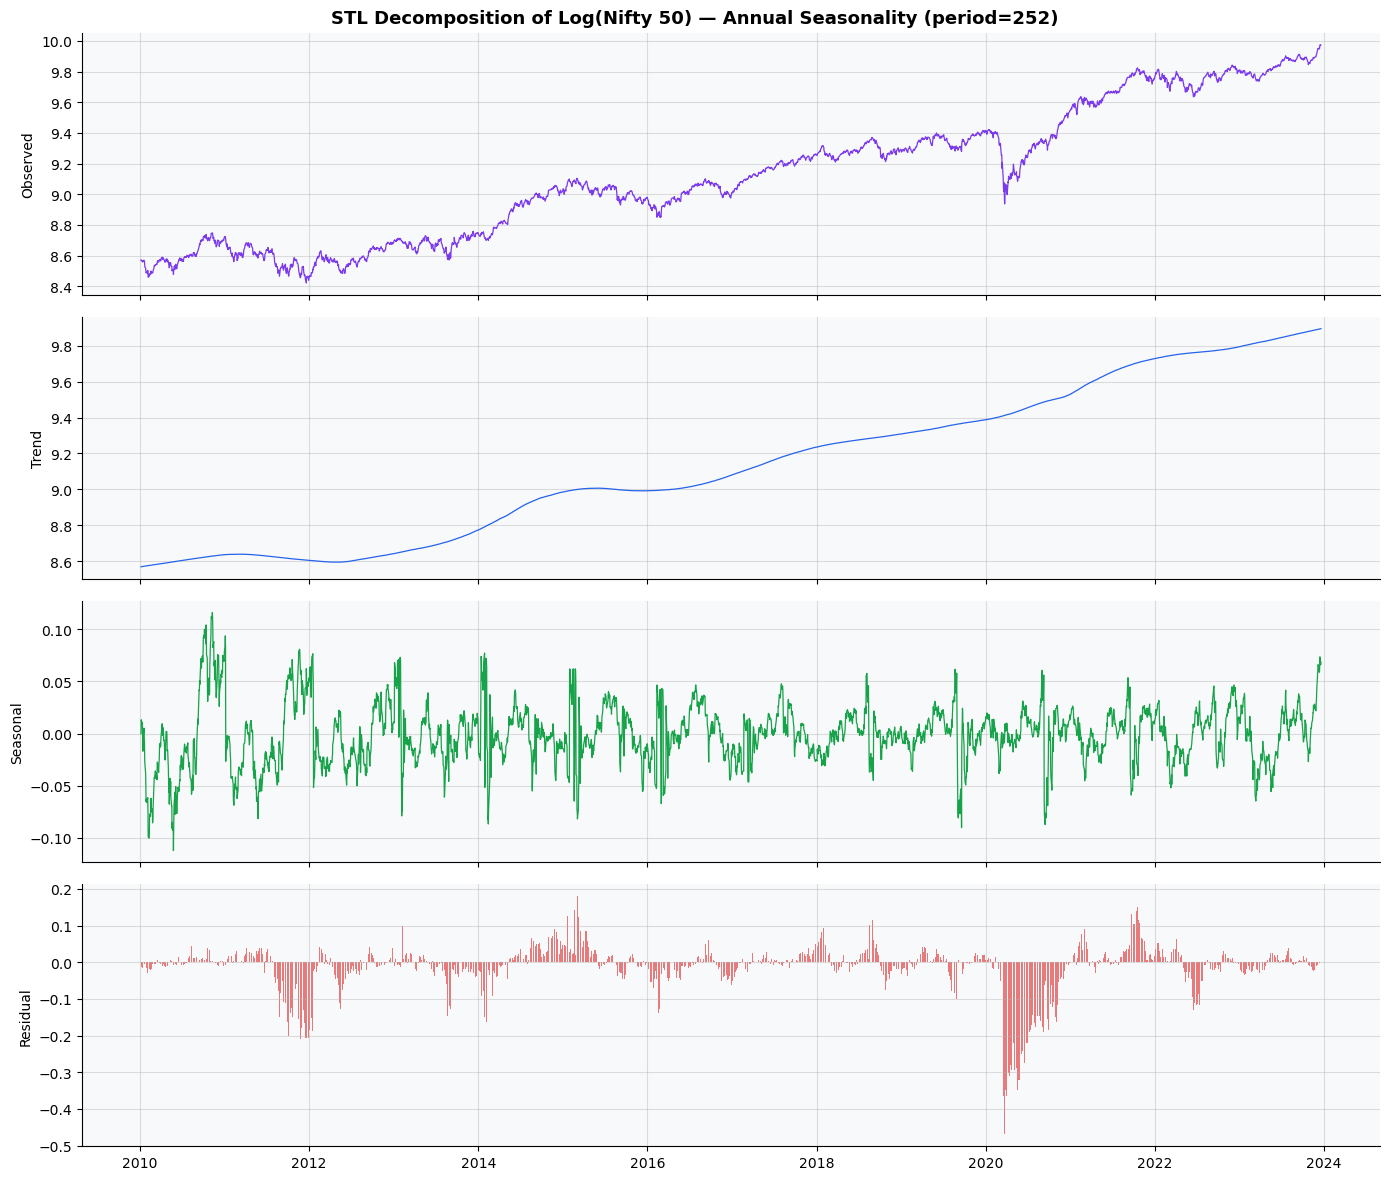

Strength of Trend    (F_T): 0.0075  (0=none, 1=strong)
Strength of Seasonal (F_S): 0.9753  (0=none, 1=strong)

Note: Strong trend expected; seasonality may be weak (daily equity index).


In [17]:
price_train = np.log(train['price'])  # STL on log-price for stability

# ── STL decomposition with different seasonal periods ─────────────────────────
# period=252 → annual cycle; period=63 → quarterly cycle
stl_annual    = STL(price_train, period=252, robust=True).fit()
stl_quarterly = STL(price_train, period=63,  robust=True).fit()

# Also run classical additive decomposition for comparison
classical = seasonal_decompose(price_train, model='additive', period=252, extrapolate_trend='freq')

# ── Plot STL (annual) ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('STL Decomposition of Log(Nifty 50) — Annual Seasonality (period=252)', 
             fontsize=13, fontweight='bold')

components = [
    (price_train,          'Observed',  PALETTE[4]),
    (stl_annual.trend,     'Trend',     PALETTE[0]),
    (stl_annual.seasonal,  'Seasonal',  PALETTE[2]),
    (stl_annual.resid,     'Residual',  PALETTE[1]),
]
for ax, (data, title, color) in zip(axes, components):
    if title == 'Residual':
        ax.bar(data.index, data, color=color, alpha=0.6, width=1)
    else:
        ax.plot(data.index, data, color=color, linewidth=0.9)
    ax.set_ylabel(title, fontsize=10)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('plots/08_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Strength of trend and seasonality
var_residual  = np.var(stl_annual.resid)
var_deseason  = np.var(stl_annual.resid + stl_annual.seasonal)
var_detrend   = np.var(stl_annual.resid + stl_annual.trend)

strength_trend    = max(0, 1 - var_residual / var_deseason)
strength_seasonal = max(0, 1 - var_residual / var_detrend)

print(f'Strength of Trend    (F_T): {strength_trend:.4f}  (0=none, 1=strong)')
print(f'Strength of Seasonal (F_S): {strength_seasonal:.4f}  (0=none, 1=strong)')
print('\nNote: Strong trend expected; seasonality may be weak (daily equity index).')

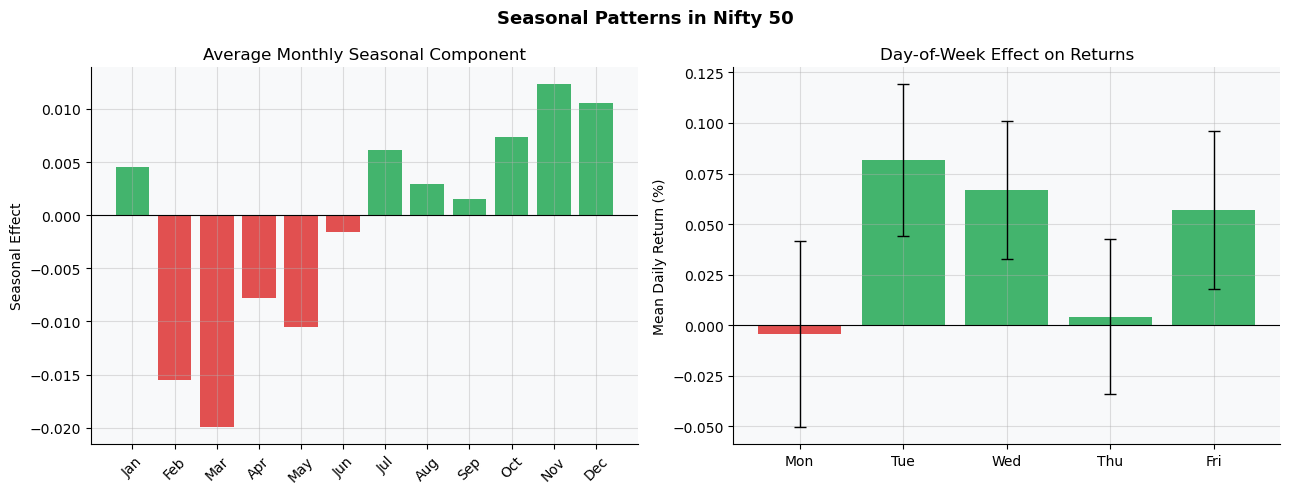

In [18]:
# ── Seasonal pattern — intra-year analysis ─────────────────────────────────────
seasonal_component = stl_annual.seasonal.copy()
seasonal_component.index = pd.to_datetime(seasonal_component.index)
monthly_seasonal = seasonal_component.groupby(seasonal_component.index.month).mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(range(1,13), monthly_seasonal.values, color=[
    PALETTE[1] if v < 0 else PALETTE[2] for v in monthly_seasonal.values], alpha=0.8)
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, rotation=45)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Monthly Seasonal Component'); ax.set_ylabel('Seasonal Effect')

# Day-of-week effect on returns
dow_returns = master['log_ret'].copy()
dow_returns.index = pd.to_datetime(dow_returns.index)
dow_mean = dow_returns.groupby(dow_returns.index.dayofweek).mean()
dow_std  = dow_returns.groupby(dow_returns.index.dayofweek).std()

ax = axes[1]
days = ['Mon','Tue','Wed','Thu','Fri']
ax.bar(days, dow_mean.values * 100, 
       color=[PALETTE[1] if v < 0 else PALETTE[2] for v in dow_mean.values], alpha=0.8)
ax.errorbar(days, dow_mean.values * 100, 
            yerr=dow_std.values * 100 / np.sqrt(len(master)//5),
            fmt='none', color='black', capsize=4, linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Day-of-Week Effect on Returns'); ax.set_ylabel('Mean Daily Return (%)')

plt.suptitle('Seasonal Patterns in Nifty 50', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_seasonality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Exponential Smoothing — Baseline Forecasts

We compare three variants:
1. **SES** (Simple Exponential Smoothing) — level only, no trend/season
2. **Holt's** (Double) — level + trend
3. **Holt-Winters** (Triple) — level + trend + seasonality

These serve as **baseline models** that our GARCH pipeline must outperform.

C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Arfeen Khan\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Arfeen Khan\anaconda3\Lib\site-pac

Exponential Smoothing Forecast Metrics (Price Level):
────────────────────────────────────────────────────────────────────────
  Simple (SES)                  RMSE=   2379.08  MAE=   1991.57  MAPE=8.21%
  Holt's (Double)               RMSE=   1733.11  MAE=   1398.89  MAPE=5.75%
  Holt-Winters (Additive)       RMSE=   1618.33  MAE=   1269.90  MAPE=5.20%

Parameters:
  SES   alpha=1.0000
  Holt  alpha=1.0000, beta=0.0000


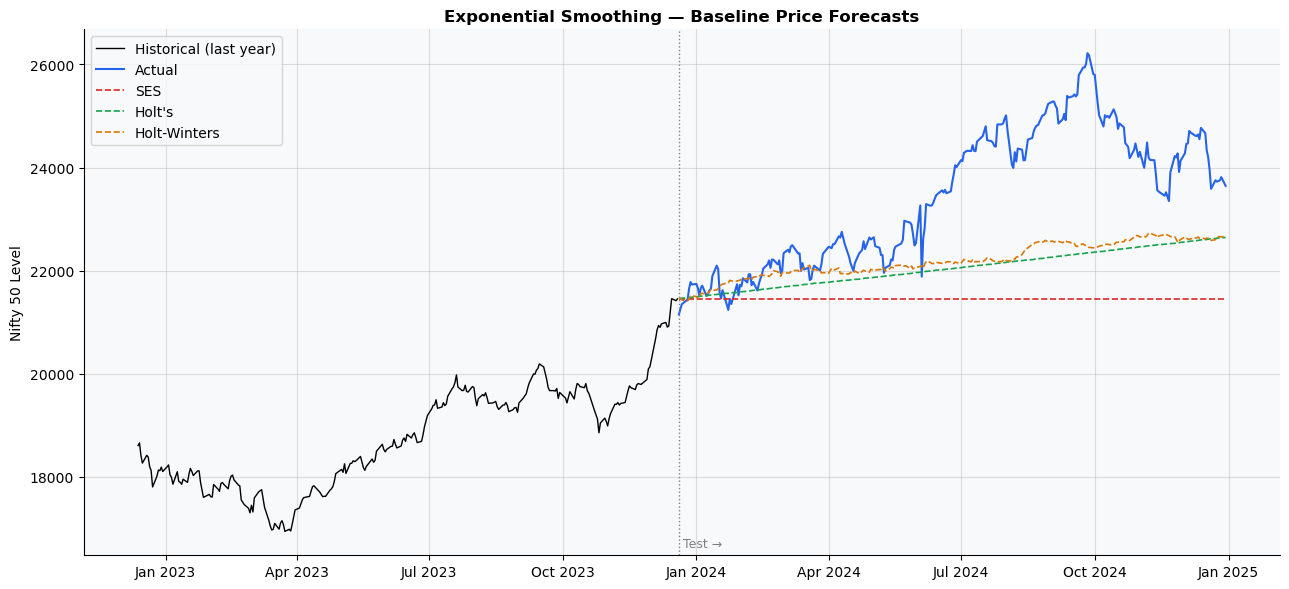

In [19]:
price_train_full = train['price']
price_test_full  = test['price']

# ── Fit models ─────────────────────────────────────────────────────────────────
ses    = SimpleExpSmoothing(price_train_full).fit(optimized=True)
holt   = ExponentialSmoothing(price_train_full, trend='add').fit(optimized=True)
hw_add = ExponentialSmoothing(price_train_full, trend='add', 
                               seasonal='add', seasonal_periods=252).fit(optimized=True)

# ── Forecasts ─────────────────────────────────────────────────────────────────
h = len(price_test_full)
fc_ses    = ses.forecast(h)
fc_holt   = holt.forecast(h)
fc_hw_add = hw_add.forecast(h)

# Set correct index
fc_ses.index    = price_test_full.index
fc_holt.index   = price_test_full.index
fc_hw_add.index = price_test_full.index

def forecast_metrics(actual, forecast, name):
    rmse = np.sqrt(np.mean((actual.values - forecast.values)**2))
    mae  = np.mean(np.abs(actual.values - forecast.values))
    mape = np.mean(np.abs((actual.values - forecast.values) / actual.values)) * 100
    print(f'  {name:<28}  RMSE={rmse:>10.2f}  MAE={mae:>10.2f}  MAPE={mape:.2f}%')
    return rmse, mae, mape

print('Exponential Smoothing Forecast Metrics (Price Level):')
print('─' * 72)
r1 = forecast_metrics(price_test_full, fc_ses,    'Simple (SES)')
r2 = forecast_metrics(price_test_full, fc_holt,   "Holt's (Double)")
r3 = forecast_metrics(price_test_full, fc_hw_add, 'Holt-Winters (Additive)')
print()
print('Parameters:')
print(f'  SES   alpha={ses.params["smoothing_level"]:.4f}')
print(f'  Holt  alpha={holt.params["smoothing_level"]:.4f}, beta={holt.params["smoothing_trend"]:.4f}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index[-252:], price_train_full.iloc[-252:], 
        color='black', linewidth=1, label='Historical (last year)')
ax.plot(price_test_full.index, price_test_full, 
        color=PALETTE[0], linewidth=1.5, label='Actual')
ax.plot(fc_ses.index,    fc_ses,    color=PALETTE[1], linewidth=1.2, linestyle='--', label='SES')
ax.plot(fc_holt.index,   fc_holt,   color=PALETTE[2], linewidth=1.2, linestyle='--', label="Holt's")
ax.plot(fc_hw_add.index, fc_hw_add, color=PALETTE[3], linewidth=1.2, linestyle='--', label='Holt-Winters')
ax.axvline(price_test_full.index[0], color='gray', linestyle=':', linewidth=1)
ax.text(price_test_full.index[0], ax.get_ylim()[0]*1.01, ' Test →', fontsize=9, color='gray')
ax.set_title('Exponential Smoothing — Baseline Price Forecasts', fontweight='bold')
ax.set_ylabel('Nifty 50 Level'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('plots/10_exponential_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model Comparison Summary

In [20]:
comparison = pd.DataFrame({
    'Model': [f'ARIMA({best_p},0,{best_q}) on returns', 'SES', "Holt's Double", 'Holt-Winters'],
    'Target': ['Log-Returns', 'Price', 'Price', 'Price'],
    'Parameters': [
        f'p={best_p}, d=0, q={best_q}',
        f'α={ses.params["smoothing_level"]:.3f}',
        f'α={holt.params["smoothing_level"]:.3f}, β={holt.params["smoothing_trend"]:.3f}',
        'Additive, period=252'
    ],
    'Key Finding': [
        'ARCH effects in residuals → GARCH needed',
        'No trend capture — naïve baseline',
        'Captures trend well',
        'Seasonal component weak'
    ]
})
print('=' * 70)
print('NOTEBOOK 2 — MODEL SUMMARY')
print('=' * 70)
print(comparison.to_string(index=False))
print()
print('KEY CONCLUSION:')
print('  ARIMA captures the conditional MEAN of returns adequately.')
print('  However, ARCH LM test confirms heteroscedasticity in residuals.')
print('  → The conditional VARIANCE is time-varying.')
print('  → Proceed to Notebook 3: ARCH / GARCH family models.')

# Save ARIMA order for use in subsequent notebooks
pd.Series({'p': best_p, 'd': 0, 'q': best_q}).to_csv('data/arima_best_order.csv')
print(f'\nSaved best ARIMA order: ({best_p}, 0, {best_q})')

NOTEBOOK 2 — MODEL SUMMARY
                  Model      Target           Parameters                              Key Finding
ARIMA(3,0,4) on returns Log-Returns        p=3, d=0, q=4 ARCH effects in residuals → GARCH needed
                    SES       Price              α=1.000        No trend capture — naïve baseline
          Holt's Double       Price     α=1.000, β=0.000                      Captures trend well
           Holt-Winters       Price Additive, period=252                  Seasonal component weak

KEY CONCLUSION:
  ARIMA captures the conditional MEAN of returns adequately.
  However, ARCH LM test confirms heteroscedasticity in residuals.
  → The conditional VARIANCE is time-varying.
  → Proceed to Notebook 3: ARCH / GARCH family models.

Saved best ARIMA order: (3, 0, 4)
